# HEA-UNet on DRIVE Retina Vessel Segmentation

This notebook demonstrates **HEA-UNet** on the standard **DRIVE** retinal vessel segmentation dataset.

It is robust to two common local layouts:

- `data/DRIVE/...`
- `examples/DRIVE/...`

It also handles the common case where **test vessel labels are not present locally** by falling back to an internal train/validation split from the labeled training images.

Metrics reported:

- masked BCE loss
- masked Dice
- masked Brier score
- masked Spiegelhalter's Z


In [1]:
import os
import random
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp/mplconfig")))

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "examples" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from local_conv_attention import HEAUNet, load_experiment_config

plt.rcParams["figure.figsize"] = (14, 4)

seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device(
    "mps"
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available()
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
print(f"Using device: {device}")


Using device: mps


In [2]:
candidate_roots = [
    PROJECT_ROOT / "data" / "DRIVE",
    PROJECT_ROOT / "examples" / "DRIVE",
]
DATA_ROOT = next((path for path in candidate_roots if path.exists()), None)
assert DATA_ROOT is not None, (
    "Could not find DRIVE under either data/DRIVE or examples/DRIVE."
)
print("Using DRIVE root:", DATA_ROOT)


Using DRIVE root: /Users/phzwart/Projects/convtrans/examples/DRIVE


In [3]:
def drive_id_from_name(path: Path) -> str:
    match = re.match(r"(\d+)_", path.stem)
    if match is None:
        raise ValueError(f"Could not parse DRIVE id from {path.name}")
    return match.group(1)


def safe_first(pattern_iter):
    return next(iter(pattern_iter), None)


def load_drive_split(split: str) -> list[dict]:
    split_root = DATA_ROOT / split
    image_dir = split_root / "images"
    manual_dir = split_root / "1st_manual"
    fov_dir = split_root / "mask"

    samples = []
    for image_path in sorted(image_dir.glob("*.tif")):
        sample_id = drive_id_from_name(image_path)
        vessel_path = safe_first(manual_dir.glob(f"{sample_id}_manual1.*")) if manual_dir.exists() else None
        fov_path = safe_first(fov_dir.glob(f"{sample_id}_*mask.*"))
        samples.append(
            {
                "id": sample_id,
                "image": image_path,
                "vessel_mask": vessel_path,
                "fov_mask": fov_path,
            }
        )
    return samples


def read_rgb(path: Path) -> np.ndarray:
    image = np.array(Image.open(path))
    if image.ndim == 2:
        image = np.stack([image] * 3, axis=-1)
    return image.astype(np.float32) / 255.0


def read_binary_mask(path: Path | None, reference_shape: tuple[int, int] | None = None) -> np.ndarray | None:
    if path is None:
        if reference_shape is None:
            return None
        return np.zeros(reference_shape, dtype=np.float32)
    mask = np.array(Image.open(path))
    if mask.ndim == 3:
        mask = mask[..., 0]
    return (mask > 0).astype(np.float32)


training_samples = load_drive_split("training")
test_samples = load_drive_split("test")
num_test_labels = sum(sample["vessel_mask"] is not None for sample in test_samples)

print("Training images:", len(training_samples))
print("Test images:", len(test_samples))
print("Test labels available:", num_test_labels)


Training images: 20
Test images: 20
Test labels available: 0


In [4]:
if num_test_labels == 0:
    print("No labeled test masks found. Falling back to an internal split of the labeled training images.")
    train_samples = training_samples[:16]
    eval_samples = training_samples[16:]
    eval_split_name = "training-heldout"
else:
    train_samples = training_samples
    eval_samples = [sample for sample in test_samples if sample["vessel_mask"] is not None]
    eval_split_name = "test"

print("Train split size:", len(train_samples))
print("Eval split size:", len(eval_samples), f"({eval_split_name})")


No labeled test masks found. Falling back to an internal split of the labeled training images.
Train split size: 16
Eval split size: 4 (training-heldout)


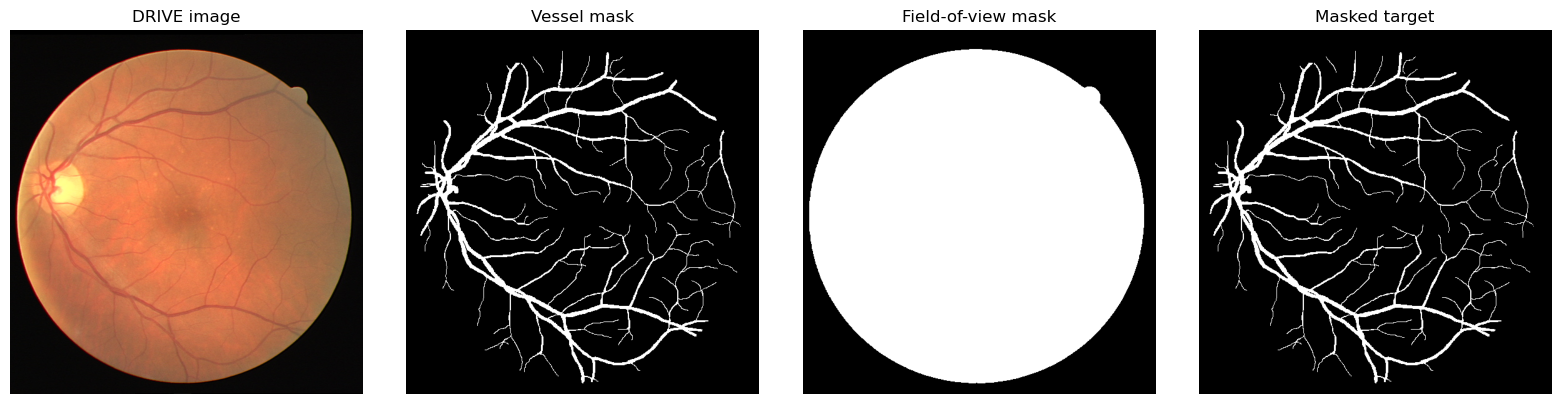

In [5]:
sample = train_samples[0]
sample_image = read_rgb(sample["image"])
sample_vessel = read_binary_mask(sample["vessel_mask"], reference_shape=sample_image.shape[:2])
sample_fov = read_binary_mask(sample["fov_mask"], reference_shape=sample_image.shape[:2])
sample_target = sample_vessel * sample_fov

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(sample_image)
axes[0].set_title("DRIVE image")
axes[1].imshow(sample_vessel, cmap="gray")
axes[1].set_title("Vessel mask")
axes[2].imshow(sample_fov, cmap="gray")
axes[2].set_title("Field-of-view mask")
axes[3].imshow(sample_target, cmap="gray")
axes[3].set_title("Masked target")
for ax in axes:
    ax.axis("off")
plt.tight_layout()


In [6]:
class DriveRetinaDataset(Dataset):
    def __init__(
        self,
        samples: list[dict],
        *,
        patch_size: int | None,
        stride: int | None = None,
        min_fg_fraction: float = 0.0,
    ) -> None:
        self.patch_size = patch_size
        self.items: list[dict] = []

        if patch_size is None:
            self.items = [{"sample": sample, "y": None, "x": None} for sample in samples]
            return

        assert stride is not None
        for sample in samples:
            image = read_rgb(sample["image"])
            vessel = read_binary_mask(sample["vessel_mask"], reference_shape=image.shape[:2])
            fov = read_binary_mask(sample["fov_mask"], reference_shape=image.shape[:2])
            target = vessel * fov
            height, width = target.shape
            for y in range(0, height - patch_size + 1, stride):
                for x in range(0, width - patch_size + 1, stride):
                    patch = target[y : y + patch_size, x : x + patch_size]
                    if patch.mean() >= min_fg_fraction:
                        self.items.append({"sample": sample, "y": y, "x": x})

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, index: int) -> dict[str, torch.Tensor]:
        item = self.items[index]
        sample = item["sample"]

        image = read_rgb(sample["image"])
        vessel = read_binary_mask(sample["vessel_mask"], reference_shape=image.shape[:2])
        fov = read_binary_mask(sample["fov_mask"], reference_shape=image.shape[:2])
        target = vessel * fov

        if self.patch_size is not None:
            y = item["y"]
            x = item["x"]
            ps = self.patch_size
            image = image[y : y + ps, x : x + ps]
            target = target[y : y + ps, x : x + ps]
            fov = fov[y : y + ps, x : x + ps]

        image_tensor = torch.from_numpy(image.transpose(2, 0, 1)).float()
        target_tensor = torch.from_numpy(target[None]).float()
        fov_tensor = torch.from_numpy(fov[None]).float()
        return {
            "image": image_tensor,
            "target": target_tensor,
            "valid_mask": fov_tensor,
            "sample_id": sample["id"],
        }


In [86]:
PATCH_SIZE = 128
PATCH_STRIDE = 96

train_dataset = DriveRetinaDataset(
    train_samples,
    patch_size=PATCH_SIZE,
    stride=PATCH_STRIDE,
    min_fg_fraction=0.01,
)
val_dataset = DriveRetinaDataset(
    eval_samples,
    patch_size=PATCH_SIZE,
    stride=PATCH_STRIDE,
    min_fg_fraction=0.01,
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

batch = next(iter(train_loader))
print("Train patches:", len(train_dataset))
print("Val patches:", len(val_dataset))
print("Image batch:", tuple(batch["image"].shape))
print("Target batch:", tuple(batch["target"].shape))
print("Valid-mask batch:", tuple(batch["valid_mask"].shape))


Train patches: 388
Val patches: 97
Image batch: (4, 3, 128, 128)
Target batch: (4, 1, 128, 128)
Valid-mask batch: (4, 1, 128, 128)


In [103]:
config = load_experiment_config(PROJECT_ROOT / "configs" / "hea_unet_small.yaml")
config.model.in_channels = 3
config.model.num_classes = 1
config.model.base_channels = 32
config.model.encoder_depths = [1,1, 1, 1]
config.model.decoder_depths = [1,1, 1]
config.model.attention.heads = 8
config.model.attention.head_dim = 16
config.model.hea.enabled_decoder_stages = [0, 1]
config.model.attention.operator_backend = "optimized"
config.model.semantic_memory.window_sizes = [7,5,3]
config.model.hea.per_scale_window_sizes = [7,5,3]
config.model.bottleneck_window_size = 3
config.validate()

model = HEAUNet(config.model).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_params = sum(parameter.numel() for parameter in model.parameters())
print(f"Model parameters: {num_params:,}")


Model parameters: 4,566,817


In [111]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)

In [116]:
def masked_bce_with_logits(logits: torch.Tensor, targets: torch.Tensor, valid_mask: torch.Tensor) -> torch.Tensor:
    per_pixel = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    per_pixel = per_pixel * valid_mask
    return per_pixel.sum() / valid_mask.sum().clamp_min(1.0)


def masked_dice_from_logits(logits: torch.Tensor, targets: torch.Tensor, valid_mask: torch.Tensor, threshold: float = 0.5) -> float:
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float() * valid_mask
    targets = targets * valid_mask
    intersection = (preds * targets).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    dice = (2.0 * intersection + 1e-6) / (union + 1e-6)
    return float(dice.mean().item())


def masked_brier_score_from_logits(logits: torch.Tensor, targets: torch.Tensor, valid_mask: torch.Tensor) -> float:
    probs = torch.sigmoid(logits)
    valid = valid_mask > 0.5
    probs = probs[valid]
    targets = targets[valid]
    return float(torch.mean((probs - targets) ** 2).item())


def masked_spiegelhalter_z_from_logits(logits: torch.Tensor, targets: torch.Tensor, valid_mask: torch.Tensor) -> float:
    probs = torch.sigmoid(logits)
    valid = valid_mask > 0.5
    probs = probs[valid]
    targets = targets[valid]

    numerator = torch.sum((targets - probs) * (1.0 - 2.0 * probs))
    denominator = torch.sqrt(torch.sum(((1.0 - 2.0 * probs) ** 2) * probs * (1.0 - probs))).clamp_min(1e-8)
    return float((numerator / denominator).item())


def run_epoch(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer | None = None) -> tuple[float, float, float, float]:
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    total_dice = 0.0
    total_brier = 0.0
    total_z = 0.0

    for batch in loader:
        images = batch["image"].to(device)
        targets = batch["target"].to(device)
        valid_mask = batch["valid_mask"].to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = masked_bce_with_logits(logits, targets, valid_mask)
            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += float(loss.item()) * images.size(0)
        total_dice += masked_dice_from_logits(logits.detach(), targets.detach(), valid_mask.detach()) * images.size(0)
        total_brier += masked_brier_score_from_logits(logits.detach(), targets.detach(), valid_mask.detach()) * images.size(0)
        total_z += masked_spiegelhalter_z_from_logits(logits.detach(), targets.detach(), valid_mask.detach()) * images.size(0)

    count = len(loader.dataset)
    return total_loss / count, total_dice / count, total_brier / count, total_z / count


history = {
    "train_loss": [],
    "train_dice": [],
    "train_brier": [],
    "train_z": [],
    "val_loss": [],
    "val_dice": [],
    "val_brier": [],
    "val_z": [],
}
EPOCHS = 15

for epoch in range(EPOCHS):
    train_loss, train_dice, train_brier, train_z = run_epoch(model, train_loader, optimizer)
    val_loss, val_dice, val_brier, val_z = run_epoch(model, val_loader, optimizer=None)

    history["train_loss"].append(train_loss)
    history["train_dice"].append(train_dice)
    history["train_brier"].append(train_brier)
    history["train_z"].append(train_z)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)
    history["val_brier"].append(val_brier)
    history["val_z"].append(val_z)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"train loss={train_loss:.4f}, dice={train_dice:.4f}, brier={train_brier:.4f}, z={train_z:.3f} | "
        f"val loss={val_loss:.4f}, dice={val_dice:.4f}, brier={val_brier:.4f}, z={val_z:.3f}"
    )


Epoch 1/15 | train loss=0.0552, dice=0.8914, brier=0.0171, z=0.169 | val loss=0.1710, dice=0.7657, brier=0.0393, z=69.278
Epoch 2/15 | train loss=0.0517, dice=0.8991, brier=0.0159, z=-0.021 | val loss=0.1865, dice=0.7502, brier=0.0406, z=78.626
Epoch 3/15 | train loss=0.0538, dice=0.8952, brier=0.0166, z=0.337 | val loss=0.1870, dice=0.7451, brier=0.0462, z=64.336
Epoch 4/15 | train loss=0.0524, dice=0.8969, brier=0.0162, z=-0.121 | val loss=0.1962, dice=0.7615, brier=0.0426, z=88.687
Epoch 5/15 | train loss=0.0468, dice=0.9079, brier=0.0144, z=0.145 | val loss=0.1779, dice=0.7731, brier=0.0399, z=76.094
Epoch 6/15 | train loss=0.0463, dice=0.9092, brier=0.0143, z=-0.120 | val loss=0.1981, dice=0.7742, brier=0.0412, z=96.049
Epoch 7/15 | train loss=0.0446, dice=0.9142, brier=0.0137, z=0.135 | val loss=0.1822, dice=0.7718, brier=0.0400, z=79.462
Epoch 8/15 | train loss=0.0437, dice=0.9152, brier=0.0134, z=0.165 | val loss=0.1961, dice=0.7699, brier=0.0407, z=94.920
Epoch 9/15 | train lo

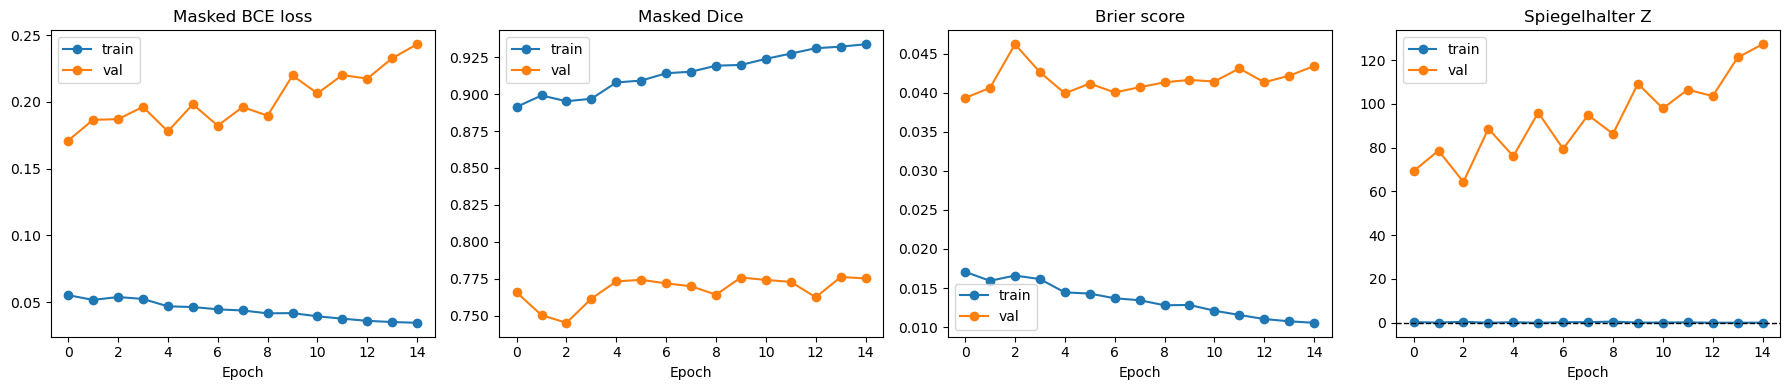

In [117]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].plot(history["train_loss"], marker="o", label="train")
axes[0].plot(history["val_loss"], marker="o", label="val")
axes[0].set_title("Masked BCE loss")
axes[0].legend()

axes[1].plot(history["train_dice"], marker="o", label="train")
axes[1].plot(history["val_dice"], marker="o", label="val")
axes[1].set_title("Masked Dice")
axes[1].legend()

axes[2].plot(history["train_brier"], marker="o", label="train")
axes[2].plot(history["val_brier"], marker="o", label="val")
axes[2].set_title("Brier score")
axes[2].legend()

axes[3].plot(history["train_z"], marker="o", label="train")
axes[3].plot(history["val_z"], marker="o", label="val")
axes[3].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[3].set_title("Spiegelhalter Z")
axes[3].legend()

for ax in axes:
    ax.set_xlabel("Epoch")
plt.tight_layout()


In [118]:
def predict_full_image(model: nn.Module, image_array: np.ndarray, patch_size: int = 128, stride: int = 96) -> np.ndarray:
    model.eval()
    height, width, _ = image_array.shape
    accum = np.zeros((height, width), dtype=np.float32)
    counts = np.zeros((height, width), dtype=np.float32)

    ys = list(range(0, max(height - patch_size + 1, 1), stride))
    xs = list(range(0, max(width - patch_size + 1, 1), stride))
    if ys[-1] != height - patch_size:
        ys.append(height - patch_size)
    if xs[-1] != width - patch_size:
        xs.append(width - patch_size)

    with torch.no_grad():
        for y in ys:
            for x in xs:
                patch = image_array[y : y + patch_size, x : x + patch_size]
                patch_tensor = torch.from_numpy(patch.transpose(2, 0, 1)).float()[None].to(device)
                logits = model(patch_tensor)
                probs = torch.sigmoid(logits)[0, 0].cpu().numpy()
                accum[y : y + patch_size, x : x + patch_size] += probs
                counts[y : y + patch_size, x : x + patch_size] += 1.0

    return accum / np.maximum(counts, 1.0)


full_eval_dataset = DriveRetinaDataset(eval_samples, patch_size=None)
full_sample = full_eval_dataset[0]
full_image = full_sample["image"].permute(1, 2, 0).numpy()
full_target = full_sample["target"][0].numpy()
full_fov = full_sample["valid_mask"][0].numpy()
sample_id = full_sample["sample_id"]

prob_map = predict_full_image(model, full_image, patch_size=PATCH_SIZE, stride=PATCH_STRIDE)
prob_map = prob_map * full_fov
pred_mask = (prob_map > 0.5).astype(np.float32)

intersection = (pred_mask * full_target).sum()
full_dice = (2.0 * intersection + 1e-6) / (pred_mask.sum() + full_target.sum() + 1e-6)
valid = full_fov > 0.5
brier = float(np.mean((prob_map[valid] - full_target[valid]) ** 2))
z_num = float(np.sum((full_target[valid] - prob_map[valid]) * (1.0 - 2.0 * prob_map[valid])))
z_den = float(np.sqrt(np.sum(((1.0 - 2.0 * prob_map[valid]) ** 2) * prob_map[valid] * (1.0 - prob_map[valid])) + 1e-8))
spiegelhalter_z = z_num / z_den

print(f"Eval split: {eval_split_name}, sample id: {sample_id}")
print(f"Full-image masked dice: {full_dice:.4f}")
print(f"Full-image Brier score: {brier:.4f}")
print(f"Full-image Spiegelhalter Z: {spiegelhalter_z:.3f}")


Eval split: training-heldout, sample id: 37
Full-image masked dice: 0.8136
Full-image Brier score: 0.0375
Full-image Spiegelhalter Z: 183.845


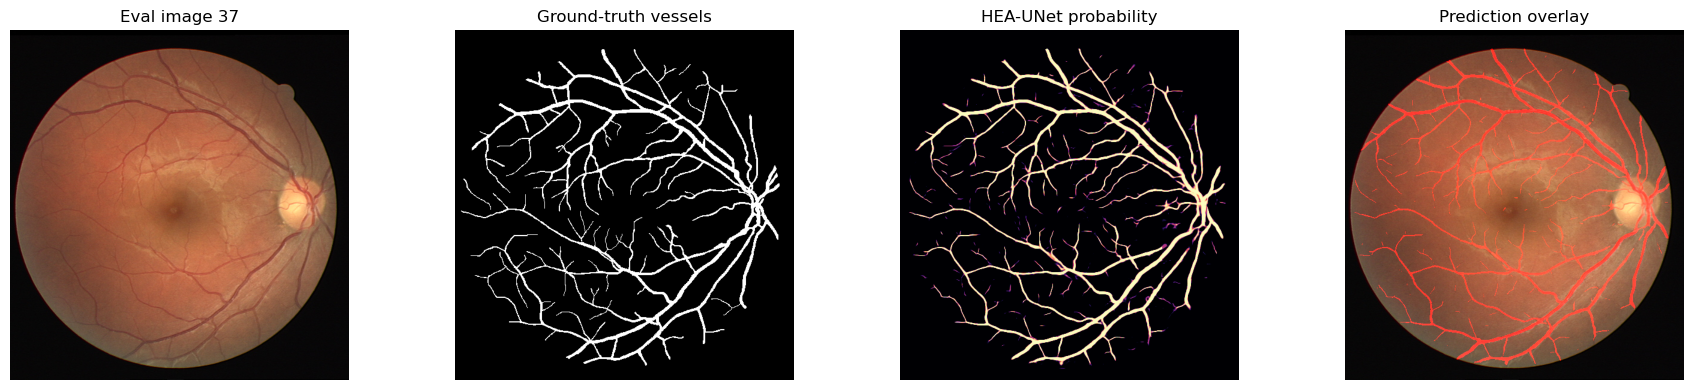

In [119]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(full_image)
axes[0].set_title(f"Eval image {sample_id}")

axes[1].imshow(full_target, cmap="gray")
axes[1].set_title("Ground-truth vessels")

axes[2].imshow(prob_map, vmin=0.0, vmax=1.0, cmap="magma")
axes[2].set_title("HEA-UNet probability")

overlay = full_image.copy()
overlay[..., 0] = np.maximum(overlay[..., 0], pred_mask)
axes[3].imshow(overlay)
axes[3].set_title("Prediction overlay")

for ax in axes:
    ax.axis("off")
plt.tight_layout()


In [120]:
import napari

In [121]:
v = napari.Viewer()

In [122]:
v.add_image(prob_map)

<Image layer 'prob_map' at 0xaeb438110>

In [123]:
v.add_image(full_image)

<Image layer 'full_image' at 0xad9a2a750>